In [3]:
#Importing
import pandas as pd
import numpy as np
import joblib
import pickle
import json
from scipy.sparse import hstack, csr_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [18]:
# ── Load processed data ───────────────────────────────────────

syn_train = pd.read_csv("../data/processed/syn_train.csv")
syn_val   = pd.read_csv("../data/processed/syn_val.csv")
syn_test  = pd.read_csv("../data/processed/syn_test.csv")

real_train = pd.read_csv("../data/processed/real_train.csv")
real_val   = pd.read_csv("../data/processed/real_val.csv")
real_test  = pd.read_csv("../data/processed/real_test.csv")

# ── Load artifacts ────────────────────────────────────────────
tfidf_syn  = joblib.load("../models/traditional/tfidf_syn.pkl")
tfidf_real = joblib.load("../models/traditional/tfidf_real.pkl")

# ── Load feature list ─────────────────────────────────────────
with open("../models/meta_features.pkl", "rb") as f:
    all_meta = pickle.load(f)

SYN_META_FEATURES  = all_meta
REAL_META_FEATURES = [f for f in all_meta if f != "domain_enc"]

print("✅ Data and artifacts loaded!")
print(f"   Syn  train/val/test : {len(syn_train)}/{len(syn_val)}/{len(syn_test)}")
print(f"   Real train/val/test : {len(real_train)}/{len(real_val)}/{len(real_test)}")

✅ Data and artifacts loaded!
   Syn  train/val/test : 3579/447/448
   Real train/val/test : 1132/378/378


In [19]:
# ── Feature builder (NO refitting inside!) ────────────────────
def build_features(df, tfidf, meta_cols):
    text_feats = tfidf.transform(df["review_text"])  # ← transform only
    meta_feats = csr_matrix(df[meta_cols].values.astype(float))
    return hstack([text_feats, meta_feats])


In [40]:
# ── Synthetic features ────────────────────────────────────────
X_syn_train = build_features(syn_train, tfidf_syn, SYN_META_FEATURES)
X_syn_val   = build_features(syn_val,   tfidf_syn, SYN_META_FEATURES)
X_syn_test  = build_features(syn_test,  tfidf_syn, SYN_META_FEATURES)
y_syn_train = syn_train["label"]
y_syn_val   = syn_val["label"]
y_syn_test  = syn_test["label"]

# ── Real features ─────────────────────────────────────────────
X_real_train = build_features(real_train, tfidf_real, REAL_META_FEATURES)
X_real_val   = build_features(real_val,   tfidf_real, REAL_META_FEATURES)
X_real_test  = build_features(real_test,  tfidf_real, REAL_META_FEATURES)
y_real_train = real_train["label"]
y_real_val   = real_val["label"]
y_real_test  = real_test["label"]

print(f"\n✅ Features built!")
print(f"   Syn  train shape : {X_syn_train.shape}")
print(f"   Real train shape : {X_real_train.shape}")


✅ Features built!
   Syn  train shape : (3579, 5013)
   Real train shape : (1132, 8012)


In [41]:
# ── Helper: evaluate model ────────────────────────────────────
def evaluate(model, X, y, split_name, target_names=["genuine","fake"]):
    preds = model.predict(X)
    print(f"\n--- {split_name} ---")
    print(classification_report(y, preds, target_names=target_names))
    return preds

def plot_confusion_matrix(y_true, y_pred, title, save_path):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["genuine","fake"],
                yticklabels=["genuine","fake"])
    plt.title(title)
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

In [42]:
# ══════════════════════════════════════════════════════════════
# PHASE 1 — PRETRAIN ON SYNTHETIC
# ══════════════════════════════════════════════════════════════
print("\n" + "="*55)
print("  PHASE 1 — PRETRAINING ON SYNTHETIC DATA")
print("="*55)

# ── Define models ─────────────────────────────────────────────
models = {
    "Logistic_Regression": LogisticRegression(
        max_iter=1000, C=1.0,
        class_weight="balanced",
        random_state=42
    ),
    "Random_Forest": RandomForestClassifier(
        n_estimators=200, max_depth=10,
        class_weight="balanced",
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=6,
        learning_rate=0.1,
        eval_metric="logloss",
        random_state=42
    ),
    "LinearSVC": LinearSVC(
        C=1.0, class_weight="balanced",
        max_iter=2000,
        random_state=42
    ),
}

# ── Train & evaluate on synthetic ────────────────────────────
pretrain_results = {}
for name, model in models.items():
    print(f"\n{'='*45}")
    print(f"  Training: {name}")
    print(f"{'='*45}")

    model.fit(X_syn_train, y_syn_train)

    # Val evaluation
    val_preds = evaluate(
        model, X_syn_val, y_syn_val,
        f"{name} — Syn Val"
    )

    pretrain_results[name] = {
        "model":     model,
        "val_preds": val_preds
    }


  PHASE 1 — PRETRAINING ON SYNTHETIC DATA

  Training: Logistic_Regression

--- Logistic_Regression — Syn Val ---
              precision    recall  f1-score   support

     genuine       0.92      0.96      0.94       218
        fake       0.96      0.92      0.94       229

    accuracy                           0.94       447
   macro avg       0.94      0.94      0.94       447
weighted avg       0.94      0.94      0.94       447


  Training: Random_Forest

--- Random_Forest — Syn Val ---
              precision    recall  f1-score   support

     genuine       0.92      0.88      0.90       218
        fake       0.89      0.93      0.91       229

    accuracy                           0.90       447
   macro avg       0.90      0.90      0.90       447
weighted avg       0.90      0.90      0.90       447


  Training: XGBoost

--- XGBoost — Syn Val ---
              precision    recall  f1-score   support

     genuine       0.93      0.97      0.95       218
        fake  

In [43]:

# ── Hyperparameter tuning ─────────────────────────────────────
print("\n" + "="*55)
print("  HYPERPARAMETER TUNING")
print("="*55)
from sklearn.model_selection import  StratifiedKFold
# from pathlib import Path
# save_dir = Path("../models/traditional/tuned")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grids = {
    "Logistic_Regression": {
        "C": [0.01, 0.1, 1, 10],
        "solver": ["liblinear", "lbfgs"]
    },
    "Random_Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [5, 10, None],
        "min_samples_split": [2, 5]
    },
    "XGBoost": {
        "n_estimators": [100, 200],
        "max_depth": [4, 6, 8],
        "learning_rate": [0.01, 0.1],
        "subsample": [0.8, 1.0]
    }
    
}

best_models = {}
for name, param_grid in param_grids.items():
    print(f"\nTuning: {name}")
    gs = GridSearchCV(
        models[name],
        param_grid,
        cv      = 5,
        scoring = "f1_weighted",
        n_jobs  = -1,
        verbose = 1
    )
    gs.fit(X_syn_train, y_syn_train)
    best_models[name] = gs.best_estimator_
    print(f"  Best params : {gs.best_params_}")
    print(f"  Best CV F1  : {gs.best_score_:.4f}")

# LinearSVC — add separately (no param grid)
best_models["LinearSVC"] = models["LinearSVC"]


# best_models = {}
# for name, model in models.items():
#     print(f"\n{'='*50}")
#     print(f"Tuning: {name}")
#     print(f"{'='*50}")

#     grid = GridSearchCV(
#         estimator=model,
#         param_grid=param_grids[name],
#         scoring="f1",              # Better than accuracy for your task
#         cv=cv,
#         n_jobs=-1,
#         verbose=1
#     )

#     grid.fit(X_train, y_train)

#     print("\nBest Parameters:")
#     print(grid.best_params_)

#     print("\nBest CV F1 Score:")
#     print(grid.best_score_)

#     # Evaluate on validation set
#     val_preds = grid.best_estimator_.predict(X_val)
#     print("\nValidation Results:")
#     print(classification_report(y_val, val_preds,
#                                 target_names=["genuine", "fake"]))

#     best_models[name] = grid.best_estimator_
#     # Save the best model with dedicated filename
#     file_path = save_dir / f"{name.replace(' ','_')}_tuned.pkl"

#     joblib.dump(grid.best_estimator_, file_path)


  HYPERPARAMETER TUNING

Tuning: Logistic_Regression
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  Best params : {'C': 10, 'solver': 'liblinear'}
  Best CV F1  : 0.9659

Tuning: Random_Forest
Fitting 5 folds for each of 18 candidates, totalling 90 fits
  Best params : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
  Best CV F1  : 0.9732

Tuning: XGBoost
Fitting 5 folds for each of 24 candidates, totalling 120 fits
  Best params : {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
  Best CV F1  : 0.9654


In [44]:
# ── Voting Ensemble ───────────────────────────────────────────
# Note: LinearSVC excluded — no predict_proba
print("\n" + "="*55)
print("  VOTING ENSEMBLE")
print("="*55)

ensemble = VotingClassifier(
    estimators=[
        ("lr",  best_models["Logistic_Regression"]),
        ("rf",  best_models["Random_Forest"]),
        ("xgb", best_models["XGBoost"]),
    ],
    voting="soft"    # predict_proba available for these 3
)
ensemble.fit(X_syn_train, y_syn_train)
best_models["Ensemble"] = ensemble

evaluate(ensemble, X_syn_val, y_syn_val, "Ensemble — Syn Val")


  VOTING ENSEMBLE

--- Ensemble — Syn Val ---
              precision    recall  f1-score   support

     genuine       0.96      0.98      0.97       218
        fake       0.98      0.96      0.97       229

    accuracy                           0.97       447
   macro avg       0.97      0.97      0.97       447
weighted avg       0.97      0.97      0.97       447



array([0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1,


  PRETRAIN — FINAL TEST RESULTS

Logistic_Regression:
              precision    recall  f1-score   support

     genuine       0.96      0.97      0.97       219
        fake       0.97      0.96      0.97       229

    accuracy                           0.97       448
   macro avg       0.97      0.97      0.97       448
weighted avg       0.97      0.97      0.97       448



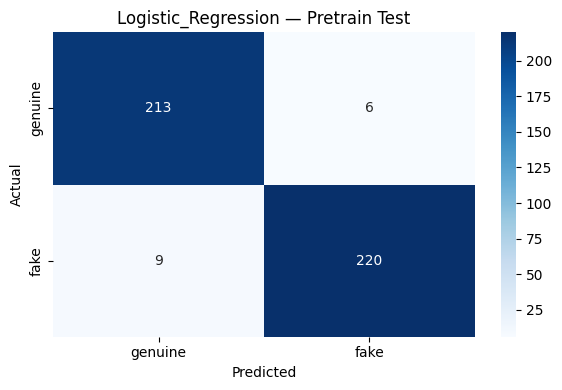


Random_Forest:
              precision    recall  f1-score   support

     genuine       0.96      0.97      0.97       219
        fake       0.97      0.97      0.97       229

    accuracy                           0.97       448
   macro avg       0.97      0.97      0.97       448
weighted avg       0.97      0.97      0.97       448



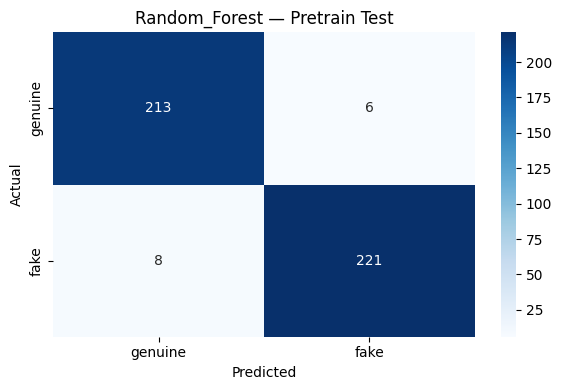


XGBoost:
              precision    recall  f1-score   support

     genuine       0.95      0.96      0.95       219
        fake       0.96      0.95      0.95       229

    accuracy                           0.95       448
   macro avg       0.95      0.95      0.95       448
weighted avg       0.95      0.95      0.95       448



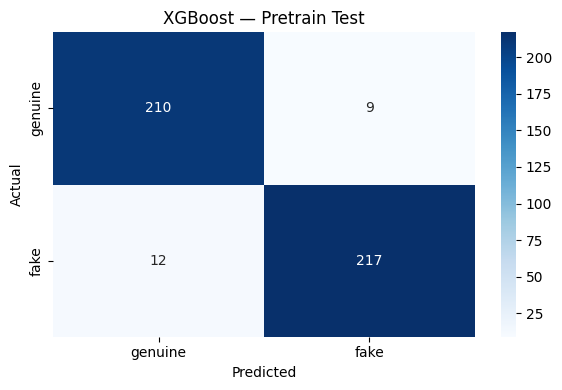


LinearSVC:
              precision    recall  f1-score   support

     genuine       0.97      0.97      0.97       219
        fake       0.97      0.97      0.97       229

    accuracy                           0.97       448
   macro avg       0.97      0.97      0.97       448
weighted avg       0.97      0.97      0.97       448



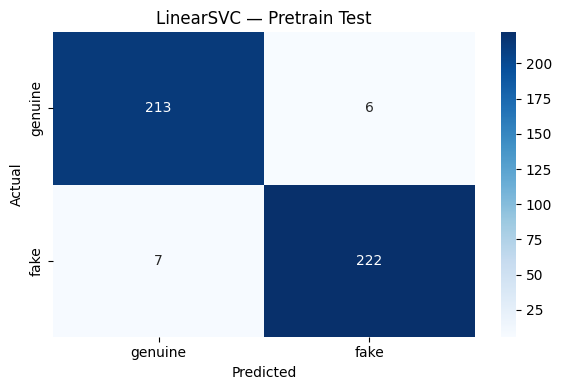


Ensemble:
              precision    recall  f1-score   support

     genuine       0.97      0.97      0.97       219
        fake       0.97      0.97      0.97       229

    accuracy                           0.97       448
   macro avg       0.97      0.97      0.97       448
weighted avg       0.97      0.97      0.97       448



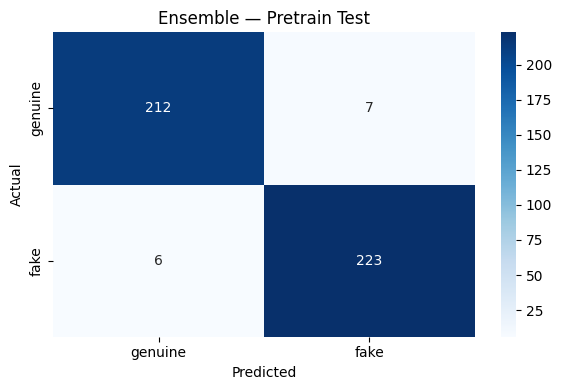


✅ Pretrained models saved!


In [45]:
# ── Final pretrain test evaluation ───────────────────────────
print("\n" + "="*55)
print("  PRETRAIN — FINAL TEST RESULTS")
print("="*55)

pretrain_test_scores = {}
for name, model in best_models.items():
    preds = model.predict(X_syn_test)
    report = classification_report(
        y_syn_test, preds,
        target_names=["genuine","fake"],
        output_dict=True
    )
    pretrain_test_scores[name] = {
        "accuracy": report["accuracy"],
        "f1":       report["weighted avg"]["f1-score"],
        "precision":report["weighted avg"]["precision"],
        "recall":   report["weighted avg"]["recall"],
    }
    print(f"\n{name}:")
    print(classification_report(
        y_syn_test, preds,
        target_names=["genuine","fake"]
    ))
    plot_confusion_matrix(
        y_syn_test, preds,
        title     = f"{name} — Pretrain Test",
        save_path = f"../results/figures/{name}_pretrain_cm.png"
    )

# ── Save pretrained models ────────────────────────────────────
for name, model in best_models.items():
    joblib.dump(
        model,
        f"../models/traditional/{name}_pretrained.pkl"
    )
print("\n✅ Pretrained models saved!")

In [46]:
# ── Save pretrained models ────────────────────────────────────
for name, model in best_models.items():
    joblib.dump(
        model,
        f"../models/traditional/{name}_pretrained.pkl"
    )
print("\n✅ Pretrained models saved!")


✅ Pretrained models saved!



  PHASE 2 — FINETUNING ON REAL DATA

  Finetuning: Logistic_Regression

--- Logistic_Regression — Real Val ---
              precision    recall  f1-score   support

     genuine       0.98      0.96      0.97       191
        fake       0.96      0.98      0.97       187

    accuracy                           0.97       378
   macro avg       0.97      0.97      0.97       378
weighted avg       0.97      0.97      0.97       378


Logistic_Regression — Real Test:
              precision    recall  f1-score   support

     genuine       0.99      0.94      0.96       191
        fake       0.94      0.99      0.96       187

    accuracy                           0.96       378
   macro avg       0.96      0.96      0.96       378
weighted avg       0.96      0.96      0.96       378



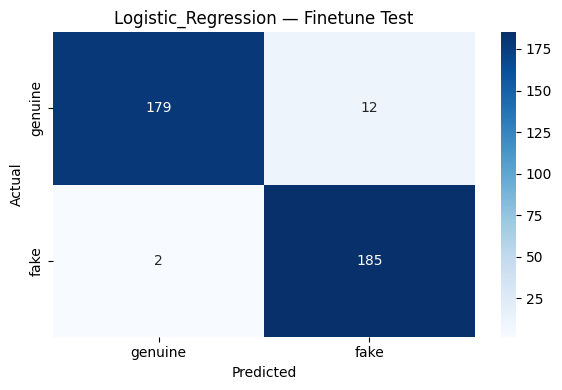


  Finetuning: Random_Forest

--- Random_Forest — Real Val ---
              precision    recall  f1-score   support

     genuine       0.99      0.97      0.98       191
        fake       0.97      0.99      0.98       187

    accuracy                           0.98       378
   macro avg       0.98      0.98      0.98       378
weighted avg       0.98      0.98      0.98       378


Random_Forest — Real Test:
              precision    recall  f1-score   support

     genuine       0.99      0.96      0.98       191
        fake       0.96      0.99      0.98       187

    accuracy                           0.98       378
   macro avg       0.98      0.98      0.98       378
weighted avg       0.98      0.98      0.98       378



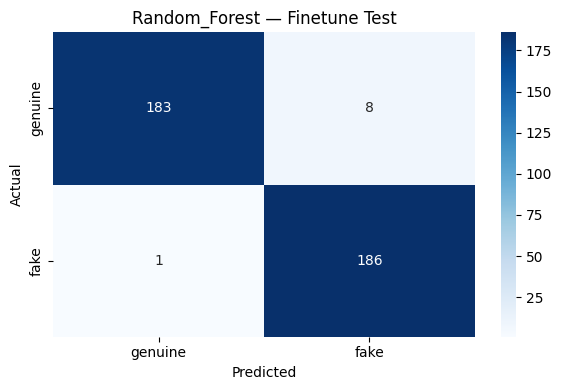


  Finetuning: XGBoost

--- XGBoost — Real Val ---
              precision    recall  f1-score   support

     genuine       0.97      0.96      0.97       191
        fake       0.96      0.97      0.97       187

    accuracy                           0.97       378
   macro avg       0.97      0.97      0.97       378
weighted avg       0.97      0.97      0.97       378


XGBoost — Real Test:
              precision    recall  f1-score   support

     genuine       0.97      0.96      0.97       191
        fake       0.96      0.97      0.97       187

    accuracy                           0.97       378
   macro avg       0.97      0.97      0.97       378
weighted avg       0.97      0.97      0.97       378



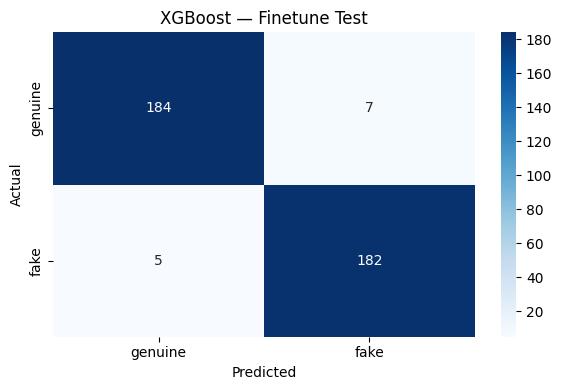


  Finetuning: LinearSVC

--- LinearSVC — Real Val ---
              precision    recall  f1-score   support

     genuine       0.99      0.97      0.98       191
        fake       0.97      0.99      0.98       187

    accuracy                           0.98       378
   macro avg       0.98      0.98      0.98       378
weighted avg       0.98      0.98      0.98       378


LinearSVC — Real Test:
              precision    recall  f1-score   support

     genuine       0.99      0.97      0.98       191
        fake       0.97      0.99      0.98       187

    accuracy                           0.98       378
   macro avg       0.98      0.98      0.98       378
weighted avg       0.98      0.98      0.98       378



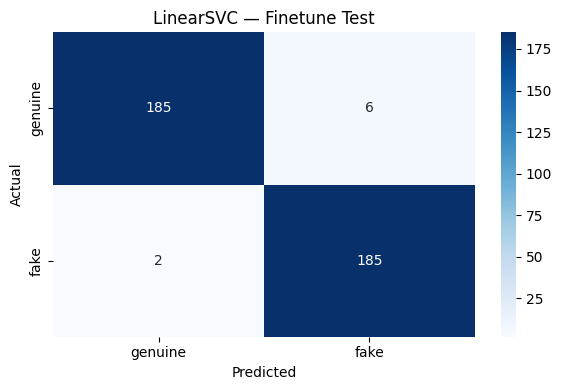


  Finetuning: Ensemble

--- Ensemble — Real Val ---
              precision    recall  f1-score   support

     genuine       0.98      0.97      0.98       191
        fake       0.97      0.98      0.98       187

    accuracy                           0.98       378
   macro avg       0.98      0.98      0.98       378
weighted avg       0.98      0.98      0.98       378


Ensemble — Real Test:
              precision    recall  f1-score   support

     genuine       0.99      0.95      0.97       191
        fake       0.95      0.99      0.97       187

    accuracy                           0.97       378
   macro avg       0.97      0.97      0.97       378
weighted avg       0.97      0.97      0.97       378



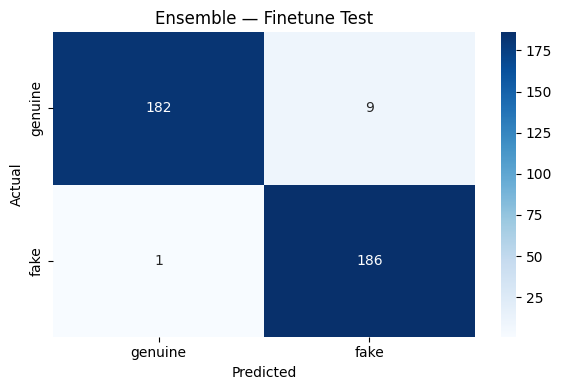


✅ Finetuned models saved!


In [47]:
# ══════════════════════════════════════════════════════════════
# PHASE 2 — FINETUNE ON REAL DATA
# ══════════════════════════════════════════════════════════════
print("\n" + "="*55)
print("  PHASE 2 — FINETUNING ON REAL DATA")
print("="*55)

finetune_test_scores = {}
finetuned_models = {}

for name, model in best_models.items():
    print(f"\n{'='*45}")
    print(f"  Finetuning: {name}")
    print(f"{'='*45}")

    # Retrain on real data
    model.fit(X_real_train, y_real_train)

    # Val evaluation
    evaluate(model, X_real_val, y_real_val, f"{name} — Real Val")

    # Test evaluation
    preds  = model.predict(X_real_test)
    report = classification_report(
        y_real_test, preds,
        target_names=["genuine","fake"],
        output_dict=True
    )
    finetune_test_scores[name] = {
        "accuracy":  report["accuracy"],
        "f1":        report["weighted avg"]["f1-score"],
        "precision": report["weighted avg"]["precision"],
        "recall":    report["weighted avg"]["recall"],
    }
    print(f"\n{name} — Real Test:")
    print(classification_report(
        y_real_test, preds,
        target_names=["genuine","fake"]
    ))
    plot_confusion_matrix(
        y_real_test, preds,
        title     = f"{name} — Finetune Test",
        save_path = f"../results/figures/{name}_finetune_cm.png"
    )

    finetuned_models[name] = model
    joblib.dump(
        model,
        f"../models/traditional/{name}_finetuned.pkl"
    )

print("\n✅ Finetuned models saved!")

In [48]:
# ══════════════════════════════════════════════════════════════
# PHASE 3 — COMPARE PRETRAIN VS FINETUNE
# ══════════════════════════════════════════════════════════════
print("\n" + "="*55)
print("  PRETRAIN vs FINETUNE COMPARISON")
print("="*55)

print(f"\n{'Model':<25} {'Pre_F1':>8} {'FT_F1':>8} {'Improvement':>12}")
print("-" * 55)
for name in best_models:
    pre_f1 = pretrain_test_scores[name]["f1"]
    ft_f1  = finetune_test_scores[name]["f1"]
    improvement = ft_f1 - pre_f1
    arrow = "↑" if improvement > 0 else "↓"
    print(f"  {name:<23} {pre_f1:>8.4f} {ft_f1:>8.4f} "
          f"{arrow}{abs(improvement):>10.4f}")


  PRETRAIN vs FINETUNE COMPARISON

Model                       Pre_F1    FT_F1  Improvement
-------------------------------------------------------
  Logistic_Regression       0.9665   0.9629 ↓    0.0036
  Random_Forest             0.9688   0.9762 ↑    0.0074
  XGBoost                   0.9531   0.9683 ↑    0.0151
  LinearSVC                 0.9710   0.9788 ↑    0.0079
  Ensemble                  0.9710   0.9735 ↑    0.0026


In [49]:
# ── Save results for notebook 06 ─────────────────────────────
ml_results = {
    "pretrain": pretrain_test_scores,
    "finetune": finetune_test_scores,
}
with open("../results/metrics/ml_results.json", "w") as f:
    json.dump(ml_results, f, indent=2)

print("\n✅ Results saved → ../results/metrics/ml_results.json")
print("\n🎯 Traditional ML notebook complete!")


✅ Results saved → ../results/metrics/ml_results.json

🎯 Traditional ML notebook complete!
